In [454]:
import numpy as np
import matplotlib.pyplot as plt

In [455]:
def generate_permutations(n):
    numbers = list(range(n))
    permutations = []

    for _ in range(n):
        permutations.append(numbers.copy())

        val = numbers.pop()
        numbers.insert(0, val)

    return permutations

In [456]:
def form_dict(n): 
    perms = generate_permutations(n)
    replaces = {}

    for idx, perm in enumerate(perms): 
        replaces[str(idx)] = ''.join([str(val) for val in perm])

    return replaces

In [457]:
def form_sequence(start, n_iter, replaces): 
    s_old, s_new = start, ''
    for _ in range(n_iter): 
        for c in s_old: 
            s_new += replaces[c]
        s_old, s_new = s_new, ''
    return s_old

In [458]:
def form_2d_sequence(start, n, n_iter): 
    replaces = form_dict(n)

    sequences = {}
    for idx in range(n): 
        sequences[str(idx)] = form_sequence(str(idx), n_iter, replaces)

    base_seq = sequences[start]

    for key, val in sequences.items(): 
        sequences[key] = np.array([int(c) for c in val], dtype=np.int8)

    result = np.zeros((len(base_seq), len(base_seq)))
    for idx, c in enumerate(base_seq): 
        result[idx] = sequences[c]

    return result

In [459]:
N = 4
n_iter = 4
seq = form_2d_sequence('0', N, n_iter)

[]

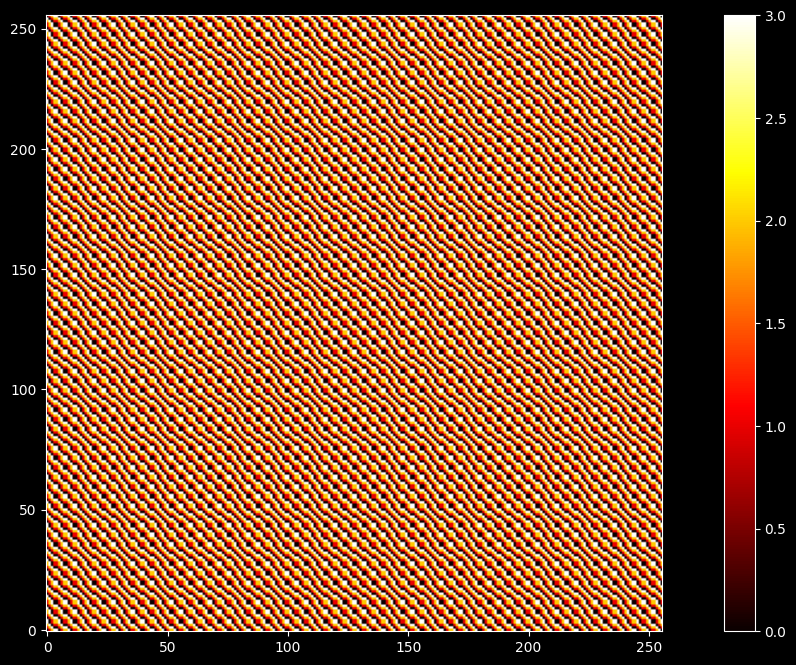

In [460]:
plt.figure(figsize=(16, 8))
plt.imshow(seq, cmap='hot', origin='lower')
plt.colorbar()
plt.plot()